In [2]:
from typing import List, TypedDict
from langgraph.graph import StateGraph
import math

In [14]:
class AgentState(TypedDict):
    """State of the agent."""
    name: str
    values: List[str]
    operator: str
    output: str

def data_processor(state: AgentState) -> AgentState:
    """Process the data in the agent's state."""
    assert state['operator'] in ["+", "*"], "Invalid operator"
    if state["operator"] == "+":
        state["output"] = f"Hi {state['name']}! Your answer is {sum(state['values'])}."
    elif state["operator"] == "*":
        state["output"] = f"Hi {state['name']}! Your answer is {math.prod(state['values'])}."
    return state

In [15]:
graph = StateGraph(AgentState)
graph.add_node('process_data', data_processor)

graph.set_entry_point('process_data')
graph.set_finish_point('process_data')

app = graph.compile()

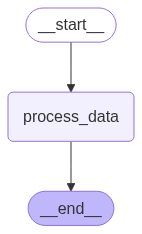

In [16]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png())) 

In [21]:
state =  AgentState(
    name='Alice',
    values=[1, 12, 3],
    operator='+',
    output='')
app.invoke(state)

{'name': 'Alice',
 'values': [1, 12, 3],
 'operator': '+',
 'output': 'Hi Alice! Your answer is 16.'}